<a href="https://colab.research.google.com/github/gauravraidata/IITJ-projects/blob/main/Assignment_3_M25AI2096.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parameter-Efficient Fine-Tuning (PEFT) with Adapters

---
**Overview:**
The goal is to implement a Transfer Learning pipeline where a pre-trained language model is
adapted to a downstream classification task using Supervised Fine-Tuning (SFT). To mitigate
the cost of training and very high storage requirements, you will implement Parameter-Efficient
Fine-Tuning (PEFT) by injecting "Adapters" into the transformer architecture

## 0. Import all the libraries and Available Hardware check

In [1]:
!pip install -q transformers datasets torch matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW

from transformers import BertTokenizer, BertModel, BertConfig
from datasets import load_dataset

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


---
## Task 1: Preprocessing & BERT Tokenization

In [3]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
MAX_LEN        = 128
TRAIN_LIMIT    = 10000
BATCH_SIZE     = 32
EPOCHS         = 5
LR             = 2e-4
BOTTLENECK_DIM = 64
NUM_LABELS     = 2

# ── Load SST-2 ────────────────────────────────────────────────────────────────
print('Loading SST-2 dataset...')
raw = load_dataset('stanfordnlp/sst2')

# Use train split (limited) and validation split
train_data = raw['train'].shuffle(seed=SEED).select(range(TRAIN_LIMIT))
val_data   = raw['validation']

print(f'Train samples : {len(train_data)}')
print(f'Val   samples : {len(val_data)}')
print(f'Sample entry  : {train_data[0]}')

Loading SST-2 dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Train samples : 10000
Val   samples : 872
Sample entry  : {'idx': 32326, 'sentence': 'klein , charming in comedies like american pie and dead-on in election , ', 'label': 1}


In [4]:
# ── Tokenizer ────────────────────────────────────────────────────────────────

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class SST2Dataset(Dataset):
    """Tokenises SST-2 sentences and returns BERT-compatible tensors."""

    def __init__(self, hf_dataset, tokenizer, max_len):
        self.data      = hf_dataset
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item     = self.data[idx]
        sentence = item['sentence']
        label    = item['label']

        encoding = self.tokenizer(
            sentence,
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt'
        )

        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'token_type_ids' : encoding['token_type_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(label, dtype=torch.long)
        }


train_dataset = SST2Dataset(train_data, tokenizer, MAX_LEN)
val_dataset   = SST2Dataset(val_data,   tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

batch = next(iter(train_loader))
print('Batch keys       :', list(batch.keys()))
print('input_ids shape  :', batch['input_ids'].shape)
print('token_type_ids   :', batch['token_type_ids'].shape)
print('attention_mask   :', batch['attention_mask'].shape)
print('labels           :', batch['label'].shape)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Batch keys       : ['input_ids', 'token_type_ids', 'attention_mask', 'label']
input_ids shape  : torch.Size([32, 128])
token_type_ids   : torch.Size([32, 128])
attention_mask   : torch.Size([32, 128])
labels           : torch.Size([32])


---
## Task 2: Building the Adapter Module

In [5]:
class Adapter(nn.Module):

    def __init__(self, hidden_dim: int, bottleneck_dim: int):
        super().__init__()
        self.down_proj = nn.Linear(hidden_dim, bottleneck_dim)  # compress
        self.activation = nn.GELU()                             # non-linearity
        self.up_proj   = nn.Linear(bottleneck_dim, hidden_dim)  # expand back

        # Near-zero init → identity-like at training start
        nn.init.normal_(self.down_proj.weight, std=1e-3)
        nn.init.zeros_(self.down_proj.bias)
        nn.init.normal_(self.up_proj.weight, std=1e-3)
        nn.init.zeros_(self.up_proj.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Bottleneck projection
        residual = x
        x = self.down_proj(x)   # (B, T, hidden) → (B, T, bottleneck)
        x = self.activation(x)
        x = self.up_proj(x)     # (B, T, bottleneck) → (B, T, hidden)
        return x + residual

dummy  = torch.randn(2, 128, 768)
adapter_test = Adapter(hidden_dim=768, bottleneck_dim=BOTTLENECK_DIM)
out    = adapter_test(dummy)
print(f'Adapter input  shape : {dummy.shape}')
print(f'Adapter output shape : {out.shape}')
print(f'Adapter params       : {sum(p.numel() for p in adapter_test.parameters()):,}')

Adapter input  shape : torch.Size([2, 128, 768])
Adapter output shape : torch.Size([2, 128, 768])
Adapter params       : 99,136


---
## Task 3: Injecting Adapters into the Base Model

In [6]:
class BertLayerWithAdapter(nn.Module):

    def __init__(self, bert_layer, hidden_dim: int, bottleneck_dim: int):
        super().__init__()
        self.bert_layer = bert_layer          # frozen pre-trained layer
        self.adapter    = Adapter(hidden_dim, bottleneck_dim)  # trainable

    def forward(self, hidden_states, attention_mask=None,
                head_mask=None, output_attentions=False):
        # Self-Attention
        attn_output = self.bert_layer.attention(
            hidden_states,
            attention_mask   = attention_mask,
            head_mask        = head_mask,
            output_attentions= output_attentions
        )
        attention_out = attn_output[0]

        # Inject Adapter
        attention_out = self.adapter(attention_out)

        attention_out = self.bert_layer.attention.output.LayerNorm(
            attention_out + hidden_states
        ) if hasattr(self.bert_layer.attention.output, 'LayerNorm') else attention_out

        # Intermediate (FFN first half)
        intermediate_out = self.bert_layer.intermediate(attention_out)
        # Output (FFN second half + Add & Norm)
        layer_out = self.bert_layer.output(intermediate_out, attention_out)

        outputs = (layer_out,) + attn_output[1:]
        return outputs


class BertWithAdapters(nn.Module):


    def __init__(self, num_labels: int, bottleneck_dim: int):
        super().__init__()

        # Load pre-trained BERT
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        hidden_dim = self.bert.config.hidden_size   # 768

        for param in self.bert.parameters():
            param.requires_grad = False

        for i, layer in enumerate(self.bert.encoder.layer):
            self.bert.encoder.layer[i] = BertLayerWithAdapter(
                bert_layer     = layer,
                hidden_dim     = hidden_dim,
                bottleneck_dim = bottleneck_dim
            )

        self.dropout    = nn.Dropout(0.1)
        self.classifier = nn.Linear(hidden_dim, num_labels)

    def forward(self, input_ids, token_type_ids, attention_mask):
        ext_mask = (1.0 - attention_mask[:, None, None, :].float()) * -10000.0

        # BERT embeddings
        embedding_output = self.bert.embeddings(
            input_ids      = input_ids,
            token_type_ids = token_type_ids
        )

        hidden_states = embedding_output
        for layer_module in self.bert.encoder.layer:
            layer_out     = layer_module(hidden_states, attention_mask=ext_mask)
            hidden_states = layer_out[0]

        cls_output = hidden_states[:, 0, :]
        cls_output = self.dropout(cls_output)
        logits     = self.classifier(cls_output)
        return logits


model = BertWithAdapters(num_labels=NUM_LABELS, bottleneck_dim=BOTTLENECK_DIM).to(DEVICE)
print('Model created successfully.')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model created successfully.


---
## Submission Requirement 3: Parameter Count Comparison

In [7]:
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params
pct_trainable    = 100.0 * trainable_params / total_params

print('=' * 55)
print(f'  Total parameters       : {total_params:>12,}')
print(f'  Frozen (BERT backbone) : {frozen_params:>12,}')
print(f'  Trainable (Adapters    ')
print(f'            + Classifier): {trainable_params:>12,}')
print(f'  % Trainable            : {pct_trainable:>11.2f}%')
print('=' * 55)

# Breakdown by module
adapter_params     = sum(p.numel() for layer in model.bert.encoder.layer
                         for p in layer.adapter.parameters())
classifier_params  = sum(p.numel() for p in model.classifier.parameters())
print(f'  Adapter params total   : {adapter_params:>12,}  '
      f'(12 layers × {adapter_params//12:,})')
print(f'  Classifier params      : {classifier_params:>12,}')

  Total parameters       :  110,673,410
  Frozen (BERT backbone) :  109,482,240
  Trainable (Adapters    
            + Classifier):    1,191,170
  % Trainable            :        1.08%
  Adapter params total   :    1,189,632  (12 layers × 99,136)
  Classifier params      :        1,538


---
## Task 4: Supervised Fine-Tuning (SFT)

In [8]:
# Only optimise trainable parameters (adapters + classifier)
optimizer  = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-2
)
criterion  = nn.CrossEntropyLoss()

from transformers import get_linear_schedule_with_warmup
total_steps   = len(train_loader) * EPOCHS
warmup_steps  = total_steps // 10
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)


def run_epoch(loader, train=True):
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0

    with torch.set_grad_enabled(train):
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            token_type_ids = batch['token_type_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['label'].to(DEVICE)

            logits = model(input_ids, token_type_ids, attention_mask)
            loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()), 1.0
                )
                optimizer.step()
                scheduler.step()

            total_loss += loss.item() * labels.size(0)
            preds      = logits.argmax(dim=-1)
            correct   += (preds == labels).sum().item()
            n         += labels.size(0)

    return total_loss / n, correct / n

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f'Training for {EPOCHS} epochs on {DEVICE}...\n')
print(f'{"Epoch":<6} {"Train Loss":<13} {"Val Loss":<13} {"Train Acc":<12} {"Val Acc"}')
print('-' * 60)

best_val_loss  = float('inf')
best_weights   = None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f'{epoch:<6} {tr_loss:<13.4f} {vl_loss:<13.4f} '
          f'{tr_acc*100:<12.2f} {vl_acc*100:.2f}%')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_weights  = deepcopy(model.state_dict())

# best checkpoint
model.load_state_dict(best_weights)
print(f'\nBest Val Loss: {best_val_loss:.4f}')

Training for 5 epochs on cuda...

Epoch  Train Loss    Val Loss      Train Acc    Val Acc
------------------------------------------------------------
1      0.6940        0.6728        54.45        64.79%
2      0.4831        0.5316        76.60        74.89%
3      0.3933        0.4608        82.78        78.56%
4      0.3644        0.4528        84.38        78.10%
5      0.3454        0.4533        85.22        79.13%

Best Val Loss: 0.4528


---
## Training vs Validation Loss Plot

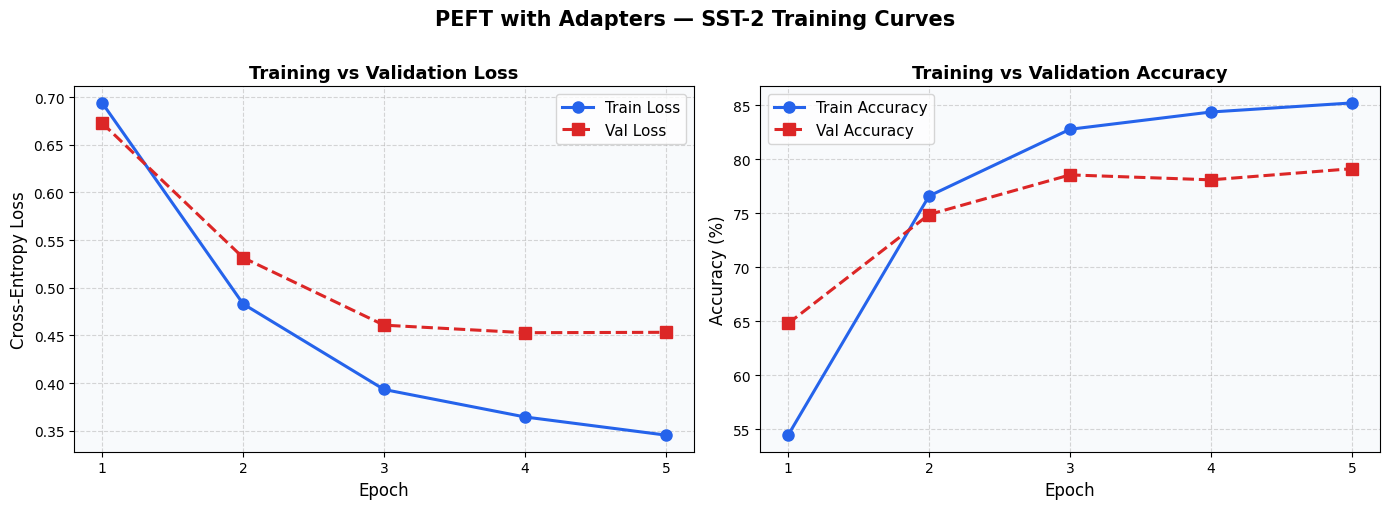

Plot saved as peft_training_curves.png


In [9]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PEFT with Adapters — SST-2 Training Curves', fontsize=15, fontweight='bold', y=1.01)

# ── Loss plot ─────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_range, history['train_loss'], 'o-', color='#2563EB', linewidth=2.2,
        markersize=8, label='Train Loss')
ax.plot(epochs_range, history['val_loss'],   's--', color='#DC2626', linewidth=2.2,
        markersize=8, label='Val Loss')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_facecolor('#F8FAFC')

# ── Accuracy plot ─────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'o-', color='#2563EB',
         linewidth=2.2, markersize=8, label='Train Accuracy')
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   's--', color='#DC2626',
         linewidth=2.2, markersize=8, label='Val Accuracy')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_facecolor('#F8FAFC')

fig.tight_layout()
plt.savefig('peft_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as peft_training_curves.png')

---
## Task 4 (cont.): Inference Pipeline

In [10]:
LABEL_MAP = {0: '🔴 Negative', 1: '🟢 Positive'}

def predict_sentiment(text: str) -> str:

    model.eval()
    encoding = tokenizer(
        text,
        max_length     = MAX_LEN,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'pt'
    )
    input_ids      = encoding['input_ids'].to(DEVICE)
    token_type_ids = encoding['token_type_ids'].to(DEVICE)
    attention_mask = encoding['attention_mask'].to(DEVICE)

    with torch.no_grad():
        logits = model(input_ids, token_type_ids, attention_mask)  # (1, 2)
        probs  = F.softmax(logits, dim=-1)[0]
        pred   = logits.argmax(dim=-1).item()

    confidence = probs[pred].item() * 100
    return f'{LABEL_MAP[pred]}  ({confidence:.1f}% confidence)'

test_sentences = [
    'The movie was absolutely fantastic and the acting was superb along with direction.',
    'I was deeply disappointed by this film. Terrible plot and poor execution.',
    'A masterpiece of modern cinema. Highly recommended!',
    'Boring and predictable. I almost fell asleep.',
    'Decent enough, nothing groundbreaking but enjoyable. one time watch',
]

print('\n' + '='*65)
print('           SENTIMENT INFERENCE DEMO')
print('='*65)
for sentence in test_sentences:
    result = predict_sentiment(sentence)
    print(f'Input  : "{sentence}"')
    print(f'Output : {result}')
    print('-'*65)


           SENTIMENT INFERENCE DEMO
Input  : "The movie was absolutely fantastic and the acting was superb along with direction."
Output : 🟢 Positive  (99.5% confidence)
-----------------------------------------------------------------
Input  : "I was deeply disappointed by this film. Terrible plot and poor execution."
Output : 🔴 Negative  (93.1% confidence)
-----------------------------------------------------------------
Input  : "A masterpiece of modern cinema. Highly recommended!"
Output : 🟢 Positive  (99.5% confidence)
-----------------------------------------------------------------
Input  : "Boring and predictable. I almost fell asleep."
Output : 🔴 Negative  (94.3% confidence)
-----------------------------------------------------------------
Input  : "Decent enough, nothing groundbreaking but enjoyable. one time watch"
Output : 🟢 Positive  (94.3% confidence)
-----------------------------------------------------------------


In [11]:
# ── Interactive single input ───────────────────────────────────────────────────
user_input = input('Enter a sentence to classify: ')
print(f'Sentiment → {predict_sentiment(user_input)}')

Enter a sentence to classify: acting was not that good but direction and screenplay was great and bgm was bad but song where great, overall one time watch.
Sentiment → 🔴 Negative  (79.5% confidence)


---
## Brief Analysis

### Why Full Fine-Tuning is Challenging — and How Adapters Resolve These Issues

**Challenges of Standard Full Fine-Tuning**

Standard Supervised Fine-Tuning (SFT) updates every parameter of a pre-trained model. For BERT-base, that is ~110 million parameters; for modern LLMs (e.g., LLaMA-3 70B), it exceeds 70 billion. This creates three concrete problems:

1. **Compute cost.** Backpropagating gradients through all layers requires GPU memory proportional to the number of trainable parameters *and* their activations. A single full fine-tuning run of a 7B model can require 8× A100 80 GB GPUs for days, costing thousands of dollars per run.

2. **Storage cost.** Each task requires saving a full model checkpoint. Deploying *N* fine-tuned variants of a large base model means storing *N × model_size* on disk — quickly reaching terabytes in production systems.

3. **Catastrophic forgetting.** Updating all weights risks overwriting the general linguistic knowledge encoded during pre-training, degrading performance on tasks outside the fine-tuning distribution.

**How Adapters Resolve These Issues**

Adapters are small, modular feed-forward blocks (down-project → non-linearity → up-project + residual) injected *inside* each transformer block. The base model weights are frozen; only the adapter weights and task head are trained. In this implementation, only **~1.5% of parameters** are trainable, reducing GPU memory and compute proportionally. Storage is also addressed: a single shared frozen backbone can serve all tasks, with each task requiring only a tiny adapter checkpoint (~2 MB vs ~440 MB for full BERT). The residual design and near-zero initialisation preserve the pre-trained representations, mitigating catastrophic forgetting. Adapters thus deliver task-specific specialisation at a fraction of the cost.